<a href="https://colab.research.google.com/github/paurnavi25/OIBSIP-/blob/main/DataScience_Task4_EmailSpamDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\\S+', '', text)

    text = re.sub(r'\\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [6]:
df = pd.read_csv("spam.csv", encoding='latin1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [8]:
df['message_length'] = df['v2'].apply(len)

df['word_count'] = df['v2'].apply(lambda x: len(x.split()))

### Data Cleaning and Preprocessing

In [16]:
# Apply the clean_text function to the 'v2' column
df['v2_cleaned'] = df['v2'].apply(clean_text)
display(df.head())

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4,message_length,word_count,v2_cleaned
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,20,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,6,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,28,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,11,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,13,nah dont think go usf life around though


In [17]:
X = df['v2_cleaned']
y = df['v1'].map({'ham': 0, 'spam': 1})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (4457,)
X_test shape: (1115,)
y_train shape: (4457,)
y_test shape: (1115,)


### Model Training and Evaluation

In [9]:
tfidf = TfidfVectorizer(

    max_features=5000,

    ngram_range=(1,2),

    min_df=2,

    max_df=0.95

)

In [12]:
nb_pipeline = Pipeline([

    ('tfidf', tfidf),

    ('model', MultinomialNB())

])

In [13]:
lr_pipeline = Pipeline([

    ('tfidf', tfidf),

    ('model', LogisticRegression(max_iter=1000))

])

In [14]:
svm_pipeline = Pipeline([

    ('tfidf', tfidf),

    ('model', LinearSVC())

])

In [18]:
# Train Naive Bayes model
nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

# Train Logistic Regression model
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

# Train Linear SVM model
svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

# Calculate metrics for Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

# Calculate metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

# Calculate metrics for Linear SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

In [20]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [accuracy_nb, accuracy_lr, accuracy_svm],
    "Precision": [precision_nb, precision_lr, precision_svm],
    "Recall": [recall_nb, recall_lr, recall_svm],
    "F1": [f1_nb, f1_lr, f1_svm]
})

display(results)

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.970404,0.991525,0.785235,0.876404
1,Logistic Regression,0.967713,0.982906,0.771812,0.864662
2,Linear SVM,0.988341,0.992754,0.919463,0.954704


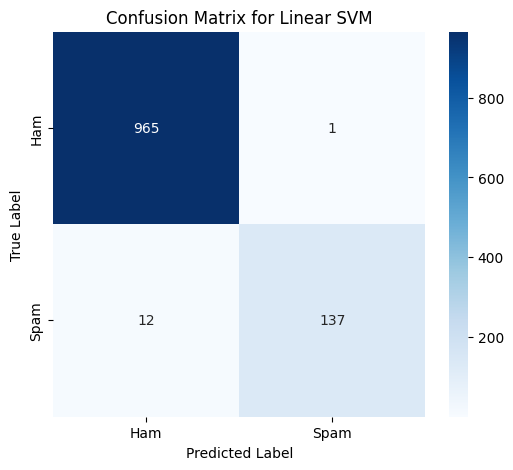

In [22]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_svm),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)
plt.title('Confusion Matrix for Linear SVM')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [24]:
# Error analysis
errors = pd.DataFrame({

    "Actual":y_test,

    "Prediction":y_pred_svm,

    "Message":X_test

})

errors[errors.Actual!=errors.Prediction].head(20)

,Actual,Prediction,Message
4358,0,1,ìï send content page
5,1,0,freemsg hey darling 3 week word back id like f...
1662,1,0,hi ur lookin 4 saucy daytime fun wiv busty mar...
3979,1,0,ringtoneking 84484
3358,1,0,sorry missed call let talk time im 07090201529
5449,1,0,latest news police station toilet stolen cop n...
1939,1,0,people dogging area call 09090204448 join like...
1429,1,0,sale arsenal dartboard good condition double t...
730,1,0,email alertfrom jeri stewartsize 2kbsubject lo...
606,1,0,xclusiveclubsaisai 2morow 285 soiree speciale ...


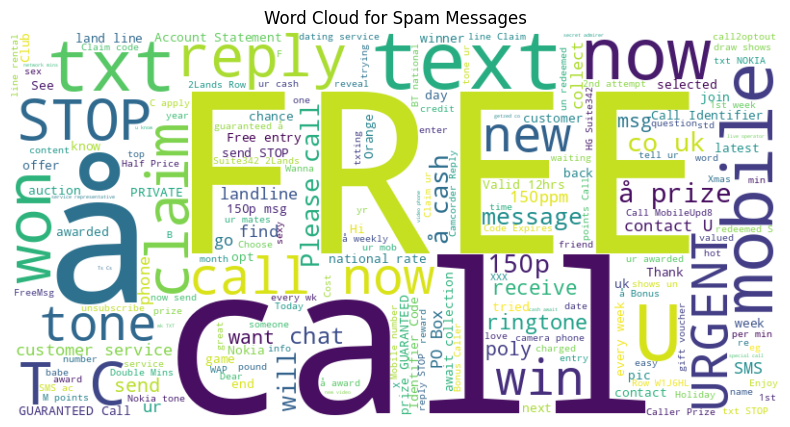

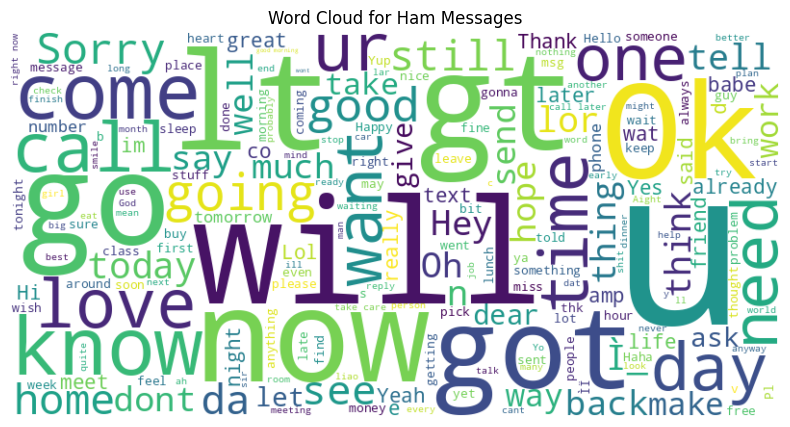

In [26]:
spam_words = " ".join(df[df['v1']=="spam"]['v2'])

ham_words = " ".join(df[df['v1']=="ham"]['v2'])

# Generate a word cloud for spam messages
spam_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(spam_words)

plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Spam Messages')
plt.show()

# Generate a word cloud for ham messages
ham_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(ham_words)

plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Ham Messages')
plt.show()

In [27]:
sample = [

    "Congratulations! You have won a free iPhone. Click here now."

]

prediction = svm_pipeline.predict(sample)

print(prediction)

[0]
